# 22. Consensus: GS vs SBI Model Assignment

Compares model assignments across four methods:
- GS-UM, GS-CP, SBI-UM, SBI-CP

Uses canonical consensus logic from `analysis.consensus`.
An animal is assigned when a majority of significant methods agree.

In [1]:
%matplotlib inline
from shared_setup import *
from analysis.consensus import load_all_assignments, consensus_summary

In [2]:
experiment, info = load_data()
assign_df = load_all_assignments(RESULTS_DIR, experiment)
print(consensus_summary(assign_df))

Loaded snapshot: 22 animals, 885 sessions (exported 2026-04-25)
22 animals total
Consensus:
  BE: 11
  Unclear: 9
  SC: 2


## 1. Full Assignment Table

In [3]:
method_cols = ['GS-UM', 'GS-CP', 'SBI-UM', 'SBI-CP']
display_cols = ['id'] + method_cols + ['Consensus']
existing = [c for c in display_cols if c in assign_df.columns]
print(assign_df[existing].to_string(index=False))

  id GS-UM GS-CP            SBI-UM            SBI-CP Consensus
SS01    BE    BE      Inconclusive      Inconclusive        BE
SS02   NaN   NaN                BE                BE        BE
SS04    BE    BE                SC                SC        SC
SS05    BE    BE                BE                BE        BE
SS06    BE    BE                BE                BE        BE
SS07    BE    SC                SC                SC        SC
SS08    BE    BE                BE                BE        BE
SS09    BE    BE                BE                BE        BE
SS10   NaN   NaN               NaN               NaN   Unclear
SS11    BE    BE                BE                BE        BE
SS12    BE    BE                BE                BE        BE
SS13    BE    BE                BE                BE        BE
SS14   NaN   NaN insufficient_data insufficient_data   Unclear
SS15   NaN   NaN               NaN               NaN   Unclear
SS16   NaN   NaN               NaN               NaN   

## 2. P-Value Summary

How significant are the assignments?

In [4]:
p_cols = [c for c in assign_df.columns if c.endswith('_p')]
if p_cols:
    p_display = ['id'] + p_cols
    print(assign_df[p_display].to_string(index=False, float_format='%.4f'))

  id  GS-UM_p  SBI-UM_p  GS-CP_p  SBI-CP_p
SS01   0.0005    0.1629   0.0004    0.7438
SS02      NaN    0.0000      NaN    0.0000
SS04   0.1438    0.0000   0.5239    0.0000
SS05   0.0000    0.0000   0.0000    0.0000
SS06   0.0010    0.0000   0.0002    0.0000
SS07   0.9779    0.0000   0.0078    0.0000
SS08   0.0000    0.0000   0.0000    0.0000
SS09   0.1024    0.0000   0.0000    0.0000
SS10      NaN       NaN      NaN       NaN
SS11   0.1966    0.0000   0.0001    0.0000
SS12   0.0007    0.0050   0.0099    0.0049
SS13   0.0000    0.0000   0.0000    0.0000
SS14      NaN       NaN      NaN       NaN
SS15      NaN       NaN      NaN       NaN
SS16      NaN       NaN      NaN       NaN
SS17      NaN       NaN      NaN       NaN
SS18      NaN       NaN      NaN       NaN
SS19      NaN       NaN      NaN       NaN
SS20      NaN    0.0000      NaN    0.0000
SS21      NaN    0.0000      NaN    0.0000
SS22      NaN       NaN      NaN       NaN
SS23      NaN       NaN      NaN       NaN


## 3. Pairwise Agreement Matrix

What fraction of shared animals get the same assignment from each pair of methods?

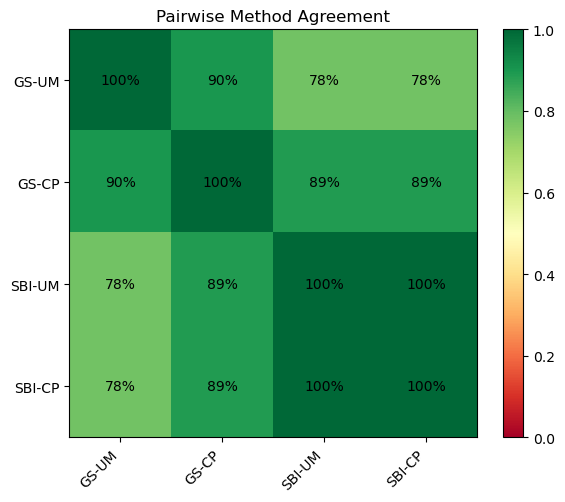

In [5]:
method_cols = ['GS-UM', 'GS-CP', 'SBI-UM', 'SBI-CP']
present = [c for c in method_cols if c in assign_df.columns]

if len(present) > 1:
    n = len(present)
    agree_matrix = np.zeros((n, n))

    for i, m1 in enumerate(present):
        for j, m2 in enumerate(present):
            valid = assign_df[m1].isin(['BE', 'SC']) & assign_df[m2].isin(['BE', 'SC'])
            if valid.sum() > 0:
                agree_matrix[i, j] = (
                    assign_df.loc[valid, m1] == assign_df.loc[valid, m2]
                ).mean()

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(agree_matrix, vmin=0, vmax=1, cmap='RdYlGn')
    ax.set_xticks(range(n))
    ax.set_xticklabels(present, rotation=45, ha='right')
    ax.set_yticks(range(n))
    ax.set_yticklabels(present)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{agree_matrix[i, j]:.0%}',
                    ha='center', va='center', fontsize=10)
    ax.set_title('Pairwise Method Agreement')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print('Need at least 2 methods to compare.')